In [116]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder_behav) if f[0:3] == 'sub']

from stress_risk.utils.data import get_data
#df = get_data(bids_folder = bids_folder_behav)
#group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


In [29]:
# decoding: look only at session 2, compare within with across sessions E (numerosity estimate)

Es_within = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within_ses_decodedE.csv')
Es_across = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/across_ses_decodedE.csv')

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)


In [84]:
from stress_risk.utils.data import add_cond2df

Es = Es_within.join(Es_across).set_index('risky_first', append=True)

Es = add_cond2df(Es)

#len(Es.reset_index()['subject'].unique()) # sub-1 ses-2 missing! 
Es['E_dif'] = Es['E_a'] - Es['E_w']
Es


E_w      sd_w       E_a      sd_a  \
subject trial_nr session risky_first                                           
1       1        1       False        2.659253  0.204591  3.122084  0.101011   
                         False        2.659253  0.204591  3.122084  0.101011   
        2        1       False        2.853814  0.301871  2.320762  0.111215   
                         False        2.853814  0.301871  2.320762  0.111215   
        3        1       False        3.557834  0.235223  2.327734  0.407480   
...                                        ...       ...       ...       ...   
61      119      2       True         1.928028  0.033986  2.436559  0.227761   
        120      1       True         2.658094  0.702908  3.617215  0.254384   
                         True         2.658094  0.702908  3.617215  0.254384   
                 2       True         4.440225  0.185782  3.617215  0.254384   
                         True         4.440225  0.185782  3.617215  0.254384   

                                        n1  group    log_n1     E_dif  
subject trial_nr session risky_first                                   
1       1        1       False        28.0      0  3.332205  0.462831  
                         False        28.0      0  3.332205  0.462831  
        2        1       False        14.0      0  2.639057 -0.533052  
                         False        14.0      0  2.639057 -0.533052  
        3        1       False        20.0      0  2.995732 -1.230100  
...                                    ...    ...       ...       ...  
61      119      2       True         34.0      0  3.526361  0.508531  
        120      1       True         42.0      0  3.737670  0.959121  
                         True         42.0      0  3.737670  0.959121  
                 2       True         42.0      0  3.737670 -0.823009  
                         True         42.0      0  3.737670 -0.823009  

[23542 rows x 8 columns]

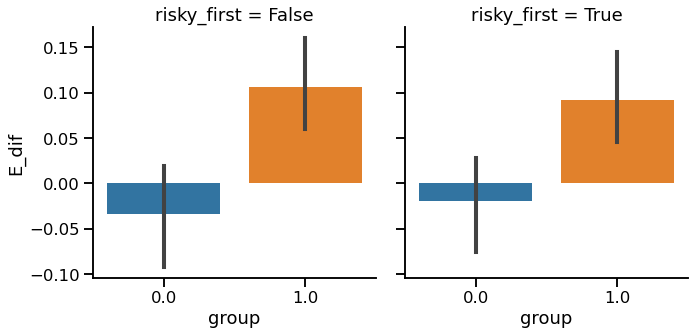

In [89]:
temp = Es.groupby(['subject', 'risky_first']).mean()
sns.set_context('talk')
sns.catplot(data=temp.reset_index(), x='group', y='E_dif', kind='bar', col='risky_first')

In [48]:
import pingouin
pingouin.corr(Es['E_w'], Es['E_a'])

,n,r,CI95%,p-val,BF10,power
pearson,11651,0.165843,"[0.15, 0.18]",1.260782e-72,3.98e+68,1.0


In [90]:
df_prior_shift = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_risky_prior.csv')

In [99]:
df_comb = df_prior_shift.join(Es.groupby(['subject']).mean()[['E_dif', 'group']]).set_index('group', append=True)

Text(0.5, 1.0, 'group all \n r=0.29, p= 0.06777')

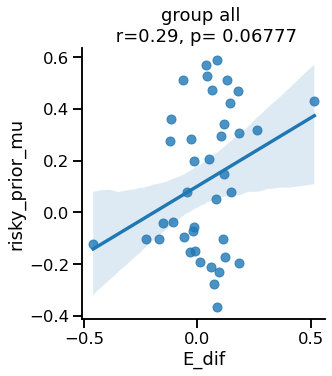

In [115]:
import matplotlib.pyplot as plt

gr = 'all'
t = df_comb#.xs(gr,0,'group')
sns.lmplot(data=t , x='E_dif', y = 'risky_prior_mu')
cor = pingouin.corr(t['E_dif'], t['risky_prior_mu'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'group {gr} \n r={r_}, p= {p}')


In [ ]:
# encoding: compare nPRF between sessions between groups

In [79]:
group_mapping

,group
subject,
1,0.0
2,0.0
3,1.0
4,1.0
5,0.0
9,0.0
10,0.0
12,0.0
13,1.0


In [83]:
from stress_risk.utils.data import add_cond2df

Es = Es_within.join(Es_across)

add_cond2df(Es)

E_w      sd_w       E_a      sd_a    n1  group  \
subject trial_nr session                                                        
1       1        1        2.659253  0.204591  3.122084  0.101011  28.0      0   
                 1        2.659253  0.204591  3.122084  0.101011  28.0      0   
        2        1        2.853814  0.301871  2.320762  0.111215  14.0      0   
                 1        2.853814  0.301871  2.320762  0.111215  14.0      0   
        3        1        3.557834  0.235223  2.327734  0.407480  20.0      0   
...                            ...       ...       ...       ...   ...    ...   
61      119      2        1.928028  0.033986  2.436559  0.227761  34.0      0   
        120      1        2.658094  0.702908  3.617215  0.254384  42.0      0   
                 1        2.658094  0.702908  3.617215  0.254384  42.0      0   
                 2        4.440225  0.185782  3.617215  0.254384  42.0      0   
                 2        4.440225  0.185782  3.617215  0.254384  42.0      0   

                         risky_first    log_n1  
subject trial_nr session                        
1       1        1             False  3.332205  
                 1             False  3.332205  
        2        1             False  2.639057  
                 1             False  2.639057  
        3        1             False  2.995732  
...                              ...       ...  
61      119      2              True  3.526361  
        120      1              True  3.737670  
                 1              True  3.737670  
                 2              True  3.737670  
                 2              True  3.737670  

[23542 rows x 8 columns]